In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

_BASE_NAMES = {
    1: "Linear ramp", 2: "Step function", 3: "Sine wave",
    4: "Multi-spike",  5: "Random walk",   6: "Quiet+burst",
}
SCENARIO_NAMES = {
    s: (_BASE_NAMES[((s - 1) % 6) + 1] if s <= 6
        else f"R{(s - 1) // 6 + 1} " + _BASE_NAMES[((s - 1) % 6) + 1])
    for s in range(1, 25)
}

# 20 distinct colors — supports up to 20 scenarios / 3 full rounds
COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628",
    "#f781bf", "#999999", "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3", "#1b9e77", "#d95f02",
    "#7570b3", "#e7298a",
]

## Завантаження та базова інформація

In [7]:
# notebooks/raw_data/data-1774627968260.csv big
# notebooks/raw_data/data-1774610506409.csv small
raw = pd.read_csv("raw_data/data-1774627968260.csv", parse_dates=["ts", "target_ts"])
raw = raw.sort_values("ts").reset_index(drop=True)

# Only input features — no predicted/actual
df = raw[["ts", "input_cpu", "input_ram", "input_rps"]].copy()
df["cpu_m"] = df["input_cpu"] * 1000   # cores → millicores

dt = df["ts"].diff().dt.total_seconds().dropna()
duration = (df["ts"].iloc[-1] - df["ts"].iloc[0]).total_seconds() / 60

print(f"Rows:      {len(df)}")
print(f"Span:      {df['ts'].iloc[0].strftime('%H:%M:%S')} → {df['ts'].iloc[-1].strftime('%H:%M:%S')} UTC  ({duration:.1f} min)")
print(f"Interval:  median={dt.median():.0f}s  std={dt.std():.1f}s  max={dt.max():.0f}s")
print()
print(df[["cpu_m", "input_rps", "input_ram"]].describe().round(2))

Rows:      2022
Span:      12:30:55 → 16:12:30 UTC  (221.6 min)
Interval:  median=5s  std=3.2s  max=20s

         cpu_m  input_rps  input_ram
count  2022.00    2022.00    2022.00
mean    562.00      10.57      51.08
std     565.53       9.81       0.74
min       1.35       0.28      49.32
25%      56.00       1.28      50.43
50%     325.80       7.58      50.96
75%    1040.94      19.69      51.68
max    1657.62      28.56      53.00


## Часові ряди: CPU, RPS, RAM

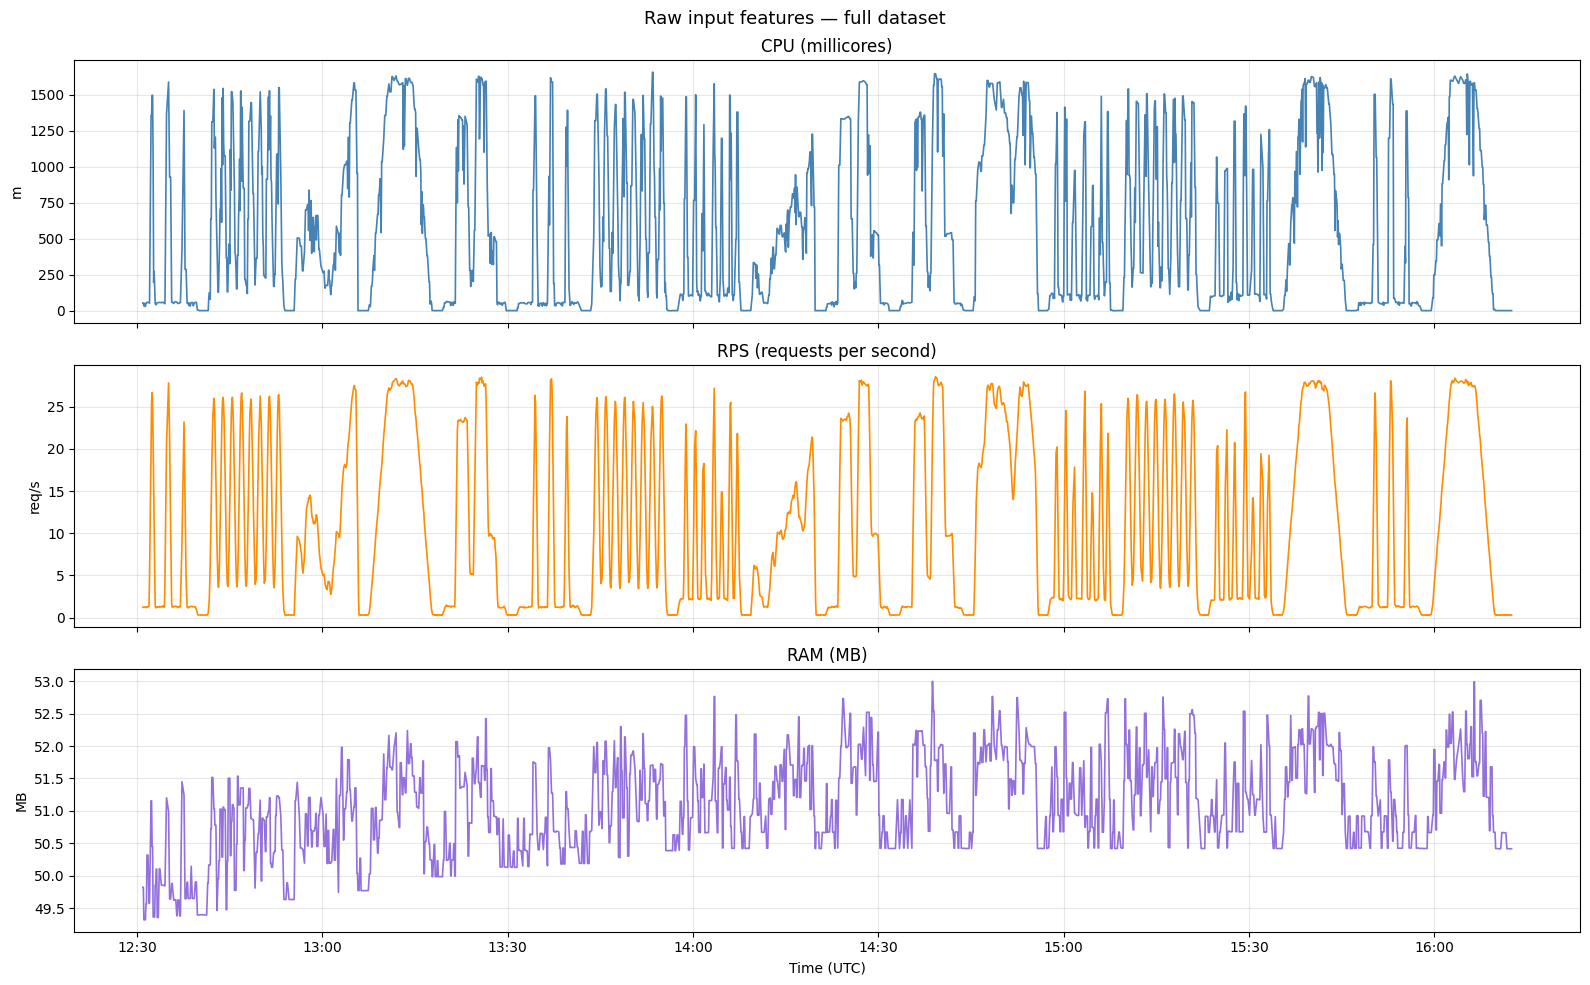

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fmt = mdates.DateFormatter("%H:%M")

axes[0].plot(df["ts"], df["cpu_m"],      color="steelblue",   linewidth=1.2)
axes[0].set_title("CPU (millicores)")
axes[0].set_ylabel("m")

axes[1].plot(df["ts"], df["input_rps"],  color="darkorange",  linewidth=1.2)
axes[1].set_title("RPS (requests per second)")
axes[1].set_ylabel("req/s")

axes[2].plot(df["ts"], df["input_ram"],  color="mediumpurple", linewidth=1.2)
axes[2].set_title("RAM (MB)")
axes[2].set_ylabel("MB")
axes[2].set_xlabel("Time (UTC)")

for ax in axes:
    ax.xaxis.set_major_formatter(fmt)

plt.suptitle("Raw input features — full dataset", fontsize=13)
plt.tight_layout()
plt.show()

## Сегментація сценаріїв

Між сценаріями Locust роздовжує паузу (~2 хв), коли RPS падає до фонового значення (<0.5 req/s).  
Знаходимо ці "тихі" проміжки і нумеруємо активні сегменти.

In [9]:
IDLE_THRESH = 0.5    # req/s — нижче цього: пауза між сценаріями
IDLE_MIN_PTS = 3     # мінімальна кількість точок для «паузи»

is_idle = df["input_rps"] < IDLE_THRESH
changes = is_idle.astype(int).diff().fillna(0)

gap_starts = df.index[changes == 1].tolist()
gap_ends   = df.index[changes == -1].tolist()

# Межі між сценаріями — початки пауз достатньої довжини
split_points = []
for gs in gap_starts:
    ends_after = [e for e in gap_ends if e > gs]
    ge = ends_after[0] if ends_after else len(df) - 1
    if ge - gs >= IDLE_MIN_PTS:
        split_points.append(gs)

# Розмічаємо сценарії
df["scenario"] = 0
segments = []
sid = 1
boundaries = [0] + split_points + [len(df)]

for i in range(len(split_points) + 1):
    seg_start = boundaries[i]
    seg_end   = split_points[i] if i < len(split_points) else len(df)
    mask = (df.index >= seg_start) & (df.index < seg_end) & ~is_idle
    if mask.sum() > 5:
        df.loc[mask, "scenario"] = sid
        t0, t1 = df.loc[mask, "ts"].iloc[0], df.loc[mask, "ts"].iloc[-1]
        segments.append((sid, t0, t1, mask.sum()))
        sid += 1

print(f"Знайдено {len(segments)} сценаріїв:\n")
for s, t0, t1, n in segments:
    dur = (t1 - t0).total_seconds() / 60
    name = SCENARIO_NAMES.get(s, "?")
    print(f"  #{s}  {name:<15}  {t0.strftime('%H:%M')}–{t1.strftime('%H:%M')}  {dur:.1f} min  {n} pts")

Знайдено 18 сценаріїв:

  #1  Linear ramp      12:30–12:39  8.8 min  76 pts
  #2  Step function    12:41–12:53  12.3 min  127 pts
  #3  Sine wave        12:55–13:05  10.2 min  87 pts
  #4  Multi-spike      13:07–13:17  10.2 min  91 pts
  #5  Random walk      13:19–13:29  10.2 min  104 pts
  #6  Quiet+burst      13:31–13:41  10.0 min  91 pts
  #7  R2 Linear ramp   13:43–13:55  12.2 min  108 pts
  #8  R2 Step function  13:57–14:07  10.3 min  96 pts
  #9  R2 Sine wave     14:09–14:19  10.2 min  99 pts
  #10  R2 Multi-spike   14:21–14:31  10.2 min  92 pts
  #11  R2 Random walk   14:33–14:43  10.2 min  90 pts
  #12  R2 Quiet+burst   14:45–14:55  10.3 min  85 pts
  #13  R3 Linear ramp   14:57–15:07  10.2 min  95 pts
  #14  R3 Step function  15:09–15:21  12.3 min  122 pts
  #15  R3 Sine wave     15:23–15:33  10.3 min  88 pts
  #16  R3 Multi-spike   15:35–15:45  10.2 min  98 pts
  #17  R3 Random walk   15:47–15:57  10.1 min  96 pts
  #18  R3 Quiet+burst   15:59–16:09  10.0 min  95 pts


## Кольорові часові ряди за сценаріями

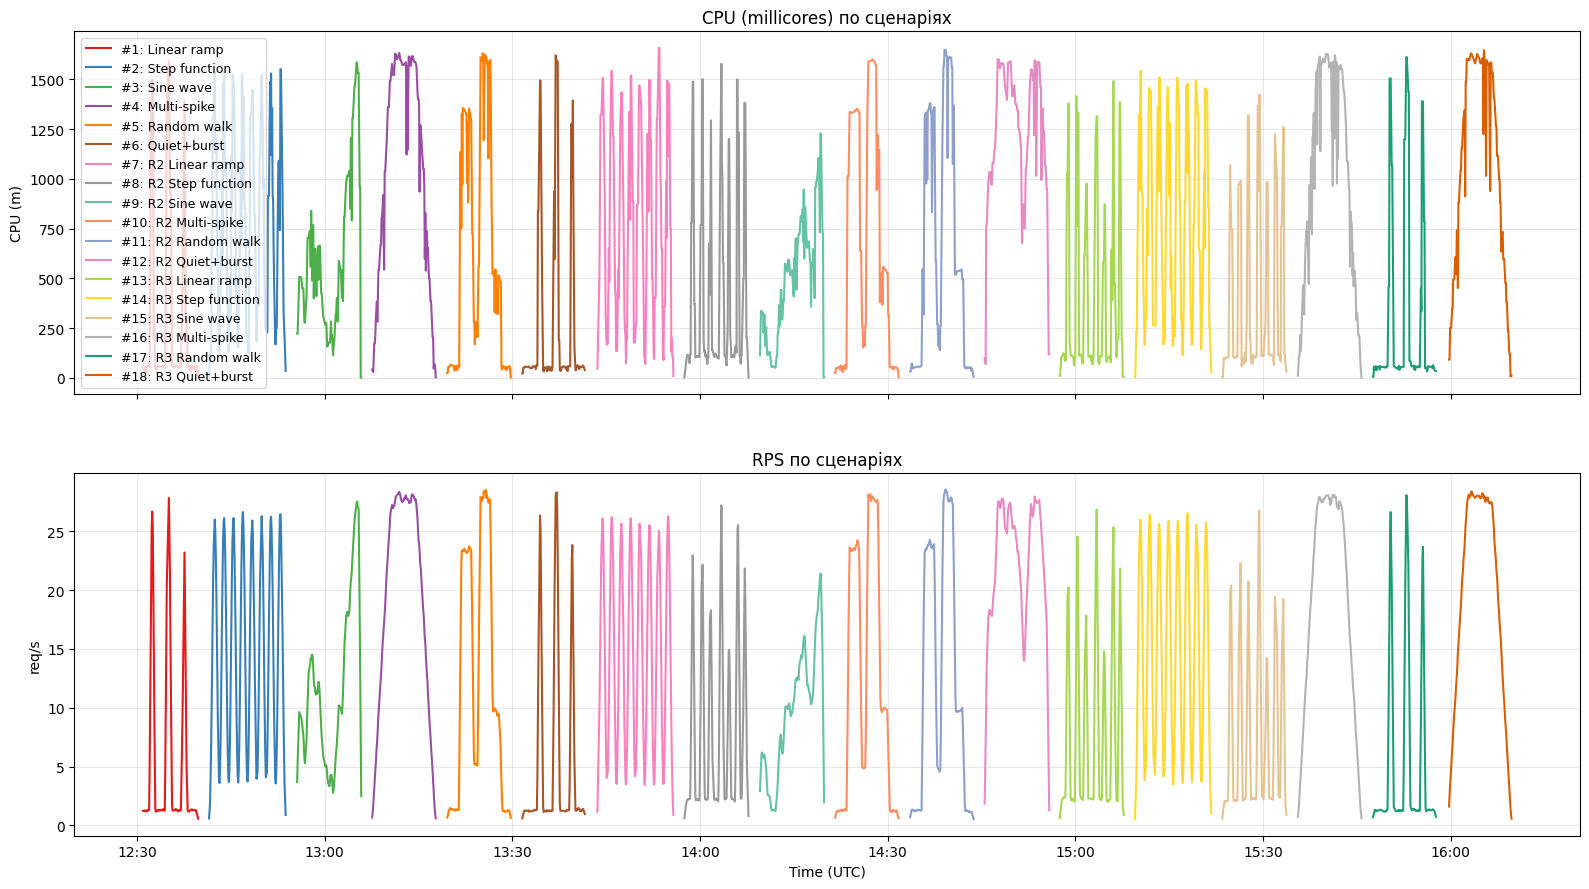

In [10]:
active_scenarios = sorted(df[df["scenario"] > 0]["scenario"].unique())

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for s in active_scenarios:
    mask = df["scenario"] == s
    c    = COLORS[s - 1]
    lbl  = f"#{s}: {SCENARIO_NAMES.get(s, '?')}"
    axes[0].plot(df.loc[mask, "ts"], df.loc[mask, "cpu_m"],      color=c, linewidth=1.5, label=lbl)
    axes[1].plot(df.loc[mask, "ts"], df.loc[mask, "input_rps"],  color=c, linewidth=1.5)

axes[0].set_title("CPU (millicores) по сценаріях")
axes[0].set_ylabel("CPU (m)")
axes[0].legend(loc="upper left", fontsize=9)

axes[1].set_title("RPS по сценаріях")
axes[1].set_ylabel("req/s")
axes[1].set_xlabel("Time (UTC)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

## Розподіли за сценаріями

/tmp/ipykernel_27582/3865549567.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=tick_labels, patch_artist=True)
/tmp/ipykernel_27582/3865549567.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=tick_labels, patch_artist=True)


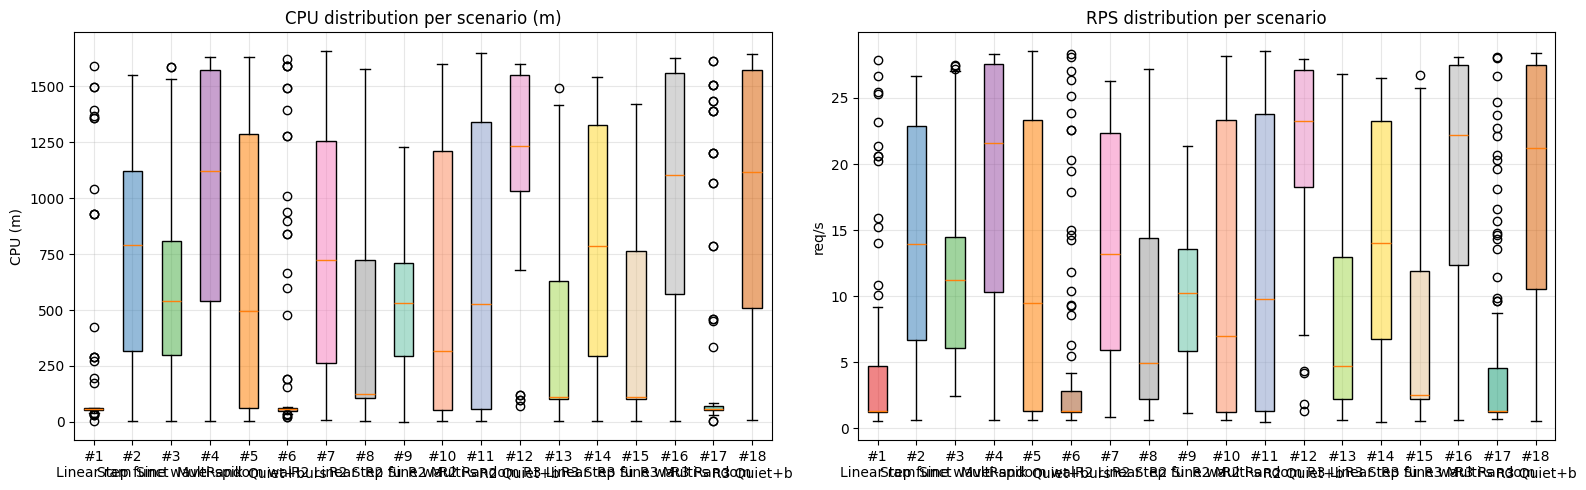


Summary statistics per scenario:
           cpu_m                input_rps             input_ram           
            mean     max    std      mean   max   std      mean   max  std
scenario                                                                  
1          248.8  1589.9  435.5       5.1  27.8   7.6      49.8  51.4  0.5
2          761.7  1550.4  472.6      14.5  26.6   8.2      50.7  51.5  0.5
3          623.8  1584.0  401.5      11.8  27.5   6.8      50.8  52.0  0.5
4         1007.1  1632.3  557.5      18.3  28.4   9.5      51.1  52.2  0.6
5          633.3  1629.3  594.7      12.0  28.5  10.5      51.0  52.4  0.7
6          260.9  1619.6  460.4       5.1  28.3   7.7      50.7  52.0  0.5
7          757.6  1657.6  514.6      14.0  26.3   8.2      51.3  52.3  0.5
8          422.8  1577.7  475.7       8.3  27.2   7.5      51.2  52.8  0.6
9          516.2  1227.6  300.6       9.9  21.4   5.3      51.4  52.4  0.5
10         577.7  1599.2  579.2      10.8  28.2  10.3      51.4  5

In [11]:
df_active = df[df["scenario"] > 0].copy()

groups_cpu = [df_active[df_active["scenario"] == s]["cpu_m"].values     for s in active_scenarios]
groups_rps = [df_active[df_active["scenario"] == s]["input_rps"].values  for s in active_scenarios]
tick_labels = [f"#{s}\n{SCENARIO_NAMES.get(s,'?')[:10]}" for s in active_scenarios]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, groups, title, ylabel in [
    (axes[0], groups_cpu, "CPU distribution per scenario (m)",  "CPU (m)"),
    (axes[1], groups_rps, "RPS distribution per scenario",      "req/s"),
]:
    bp = ax.boxplot(groups, labels=tick_labels, patch_artist=True)
    for patch, c in zip(bp["boxes"], COLORS):
        patch.set_facecolor(c + "88")
    ax.set_title(title)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

print("\nSummary statistics per scenario:")
print(
    df_active.groupby("scenario")[["cpu_m", "input_rps", "input_ram"]]
    .agg(["mean", "max", "std"])
    .round(1)
    .to_string()
)

## Залежність RPS → CPU

Ключова гіпотеза: RPS є хорошим провісником CPU.  
Перевіряємо лінійну кореляцію по кожному сценарію окремо та в цілому.

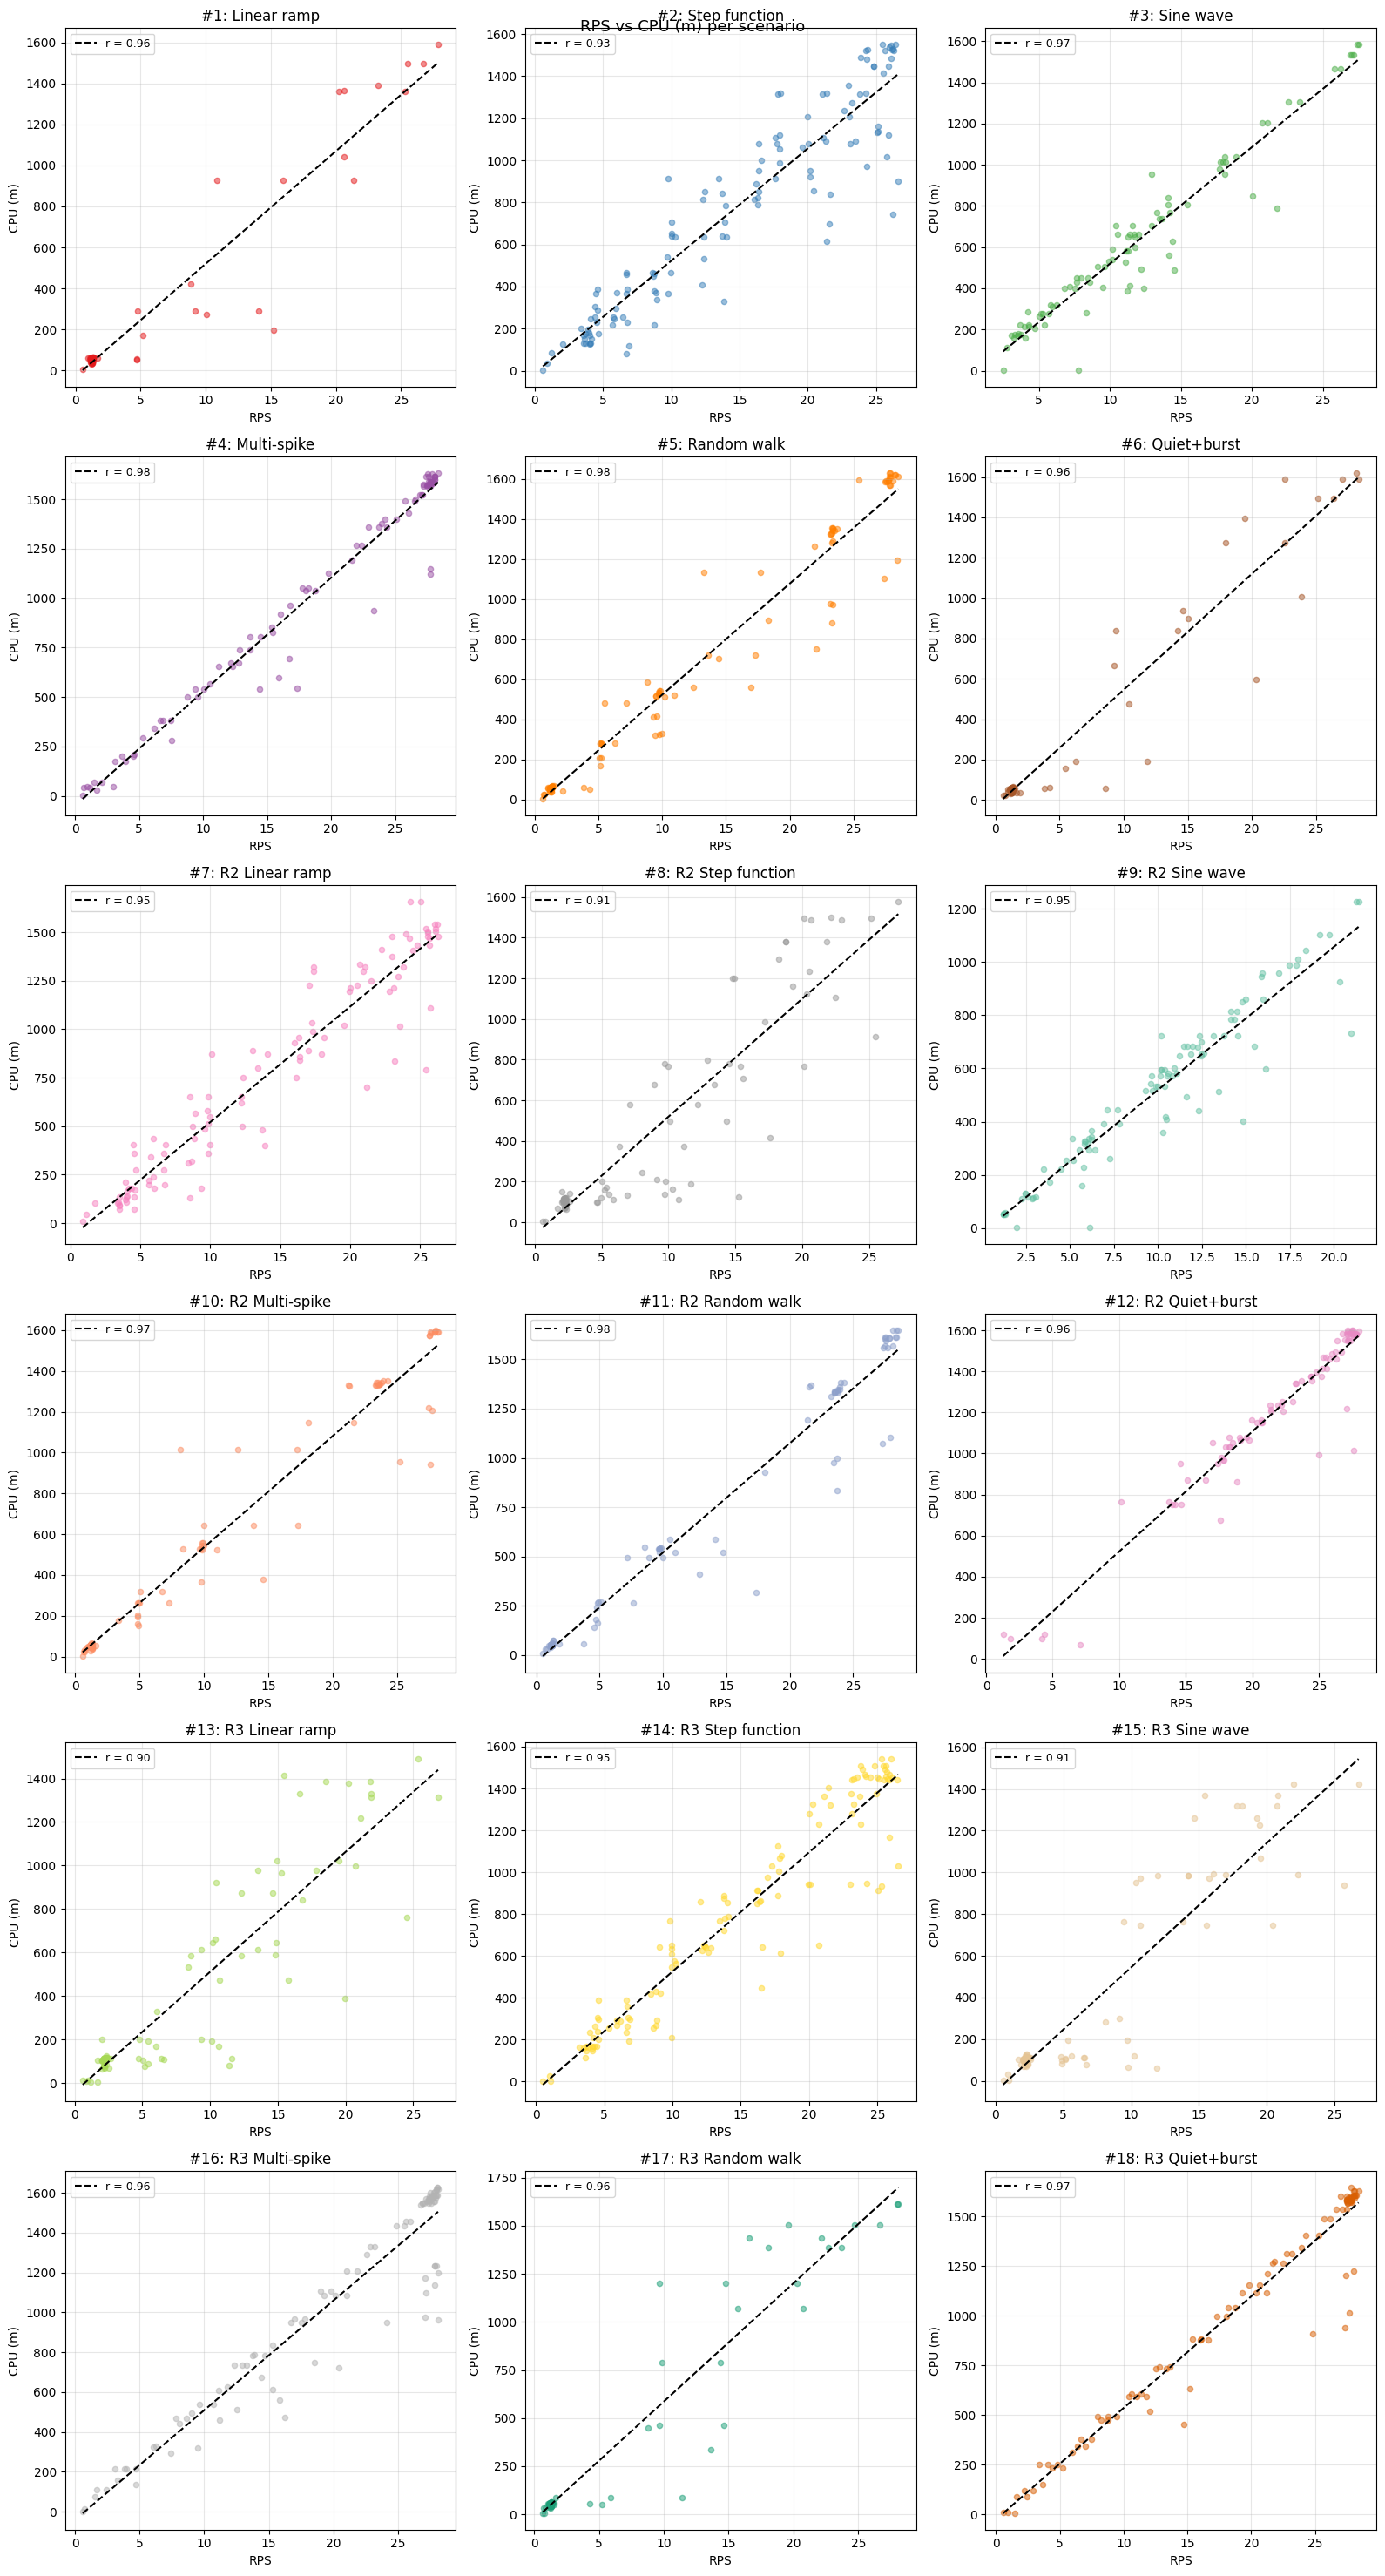

Overall Pearson r(RPS, CPU):  0.965  (p = 0.00e+00)


In [12]:
n_scen = len(active_scenarios)
ncols = 3
nrows = (n_scen + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, s in enumerate(active_scenarios):
    mask = df["scenario"] == s
    x = df.loc[mask, "input_rps"].values
    y = df.loc[mask, "cpu_m"].values
    axes[i].scatter(x, y, alpha=0.5, s=20, color=COLORS[i])
    if len(x) > 5:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(xline, slope * xline + intercept, "k--", linewidth=1.5, label=f"r = {r:.2f}")
        axes[i].legend(fontsize=9)
    axes[i].set_title(f"#{s}: {SCENARIO_NAMES.get(s, '?')}")
    axes[i].set_xlabel("RPS")
    axes[i].set_ylabel("CPU (m)")

# Hide spare axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("RPS vs CPU (m) per scenario", fontsize=13)
plt.tight_layout()
plt.show()

r_all, p_all = stats.pearsonr(df_active["input_rps"], df_active["cpu_m"])
print(f"Overall Pearson r(RPS, CPU):  {r_all:.3f}  (p = {p_all:.2e})")

## Log-returns (вхід моделі)

Модель навчається на логарифмічних приростах, а не на абсолютних значеннях.  
Дивимось, як вони виглядають, і чи дійсно забезпечують стаціонарність.

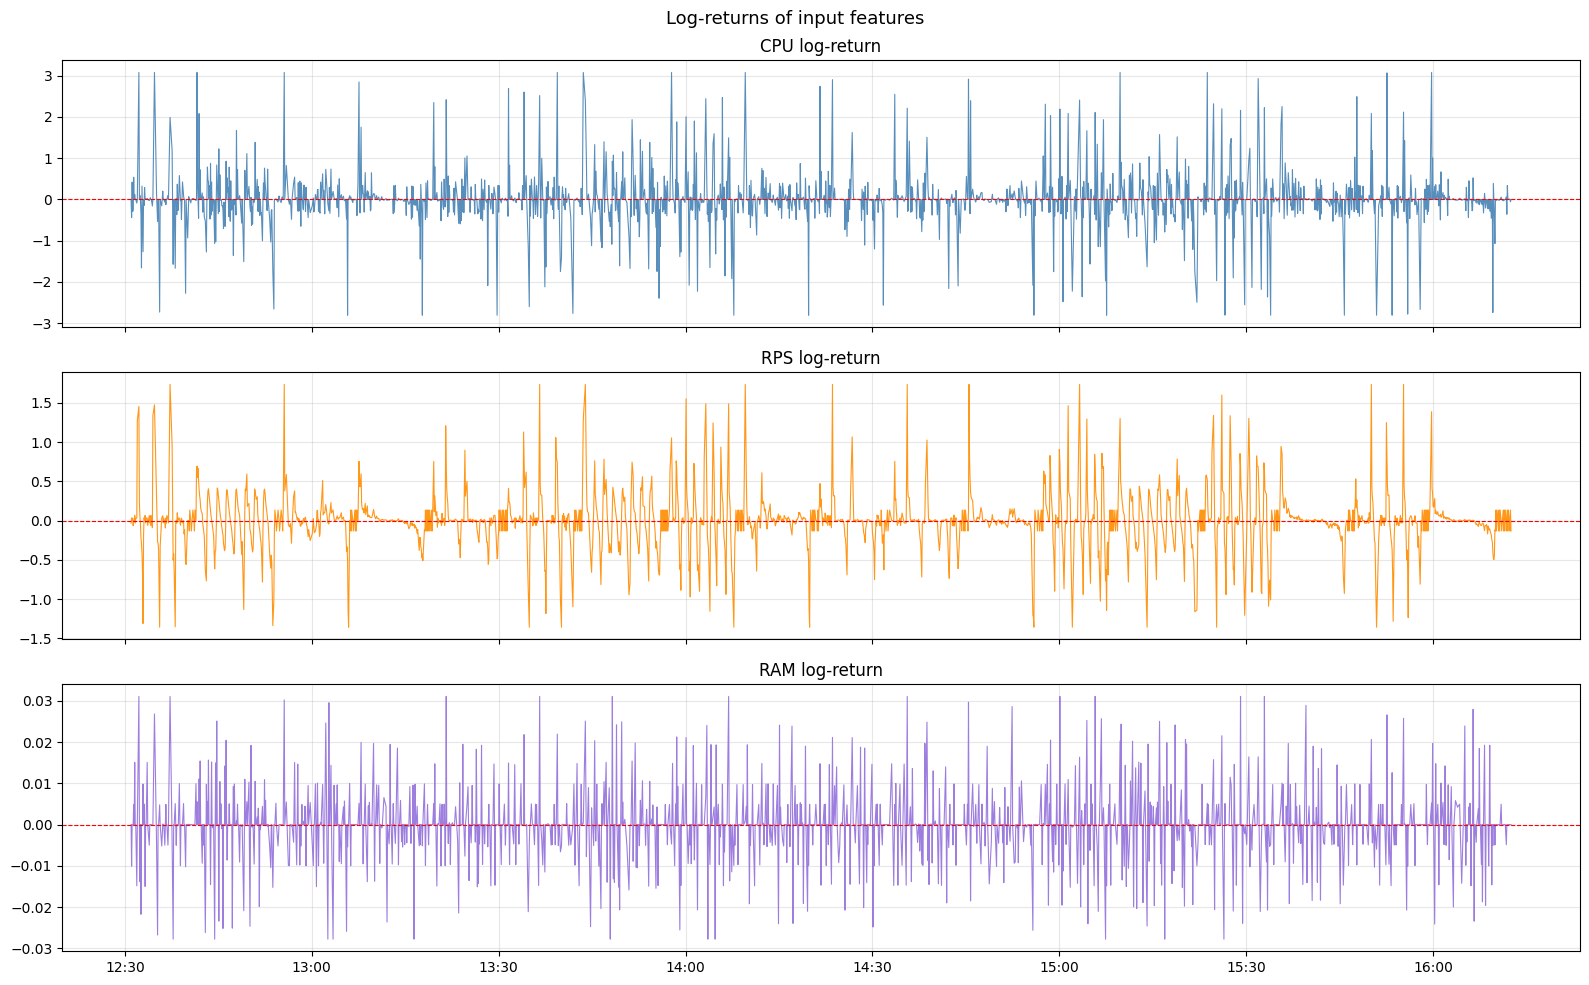

Log-return statistics:
          lr_cpu     lr_rps     lr_ram
count  2021.0000  2021.0000  2021.0000
mean      0.0009    -0.0004    -0.0000
std       0.6525     0.3556     0.0079
min      -2.8074    -1.3589    -0.0278
25%      -0.0997    -0.1056     0.0000
50%       0.0000     0.0000     0.0000
75%       0.0413     0.0946     0.0000
max       3.0790     1.7341     0.0311


In [13]:
eps = 1e-9
lr = pd.DataFrame({
    "ts":     df["ts"],
    "lr_cpu": np.log(df["input_cpu"] + eps).diff(),
    "lr_rps": np.log(df["input_rps"] + eps).diff(),
    "lr_ram": np.log(df["input_ram"] + eps).diff(),
}).dropna()

# Clip 0.5% outliers for visualization
for col in ["lr_cpu", "lr_rps", "lr_ram"]:
    lo, hi = lr[col].quantile([0.005, 0.995])
    lr[col] = lr[col].clip(lo, hi)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, col, color, title in zip(
    axes,
    ["lr_cpu", "lr_rps", "lr_ram"],
    ["steelblue", "darkorange", "mediumpurple"],
    ["CPU log-return", "RPS log-return", "RAM log-return"],
):
    ax.plot(lr["ts"], lr[col], color=color, linewidth=0.8, alpha=0.9)
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.suptitle("Log-returns of input features", fontsize=13)
plt.tight_layout()
plt.show()

print("Log-return statistics:")
print(lr[["lr_cpu", "lr_rps", "lr_ram"]].describe().round(4))

## Стаціонарність — ADF test

H₀: ряд **нестаціонарний**. p < 0.05 → відкидаємо H₀ → ряд **стаціонарний**.

In [14]:
series_to_test = [
    ("input_cpu   (raw)",        df["input_cpu"]),
    ("input_rps   (raw)",        df["input_rps"]),
    ("input_ram   (raw)",        df["input_ram"]),
    ("lr_cpu  (log-return)",     lr["lr_cpu"]),
    ("lr_rps  (log-return)",     lr["lr_rps"]),
    ("lr_ram  (log-return)",     lr["lr_ram"]),
]

print(f"{'Series':<30}  {'ADF stat':>10}  {'p-value':>10}  {'Result'}")
print("-" * 65)
for name, series in series_to_test:
    adf_stat, p, *_ = adfuller(series.dropna())
    result = "✓ stationary" if p < 0.05 else "✗ non-stationary"
    print(f"  {name:<28}  {adf_stat:>10.3f}  {p:>10.4f}  {result}")

Series                            ADF stat     p-value  Result
-----------------------------------------------------------------
  input_cpu   (raw)                 -6.970      0.0000  ✓ stationary
  input_rps   (raw)                 -6.491      0.0000  ✓ stationary
  input_ram   (raw)                 -5.360      0.0000  ✓ stationary
  lr_cpu  (log-return)             -19.160      0.0000  ✓ stationary
  lr_rps  (log-return)             -21.206      0.0000  ✓ stationary
  lr_ram  (log-return)             -17.932      0.0000  ✓ stationary


## Автокореляція log-returns CPU (ACF / PACF)

Показує, чи є в ряду пам'ять і скільки лагів реально несуть інформацію → підказка для `window_size` моделі.

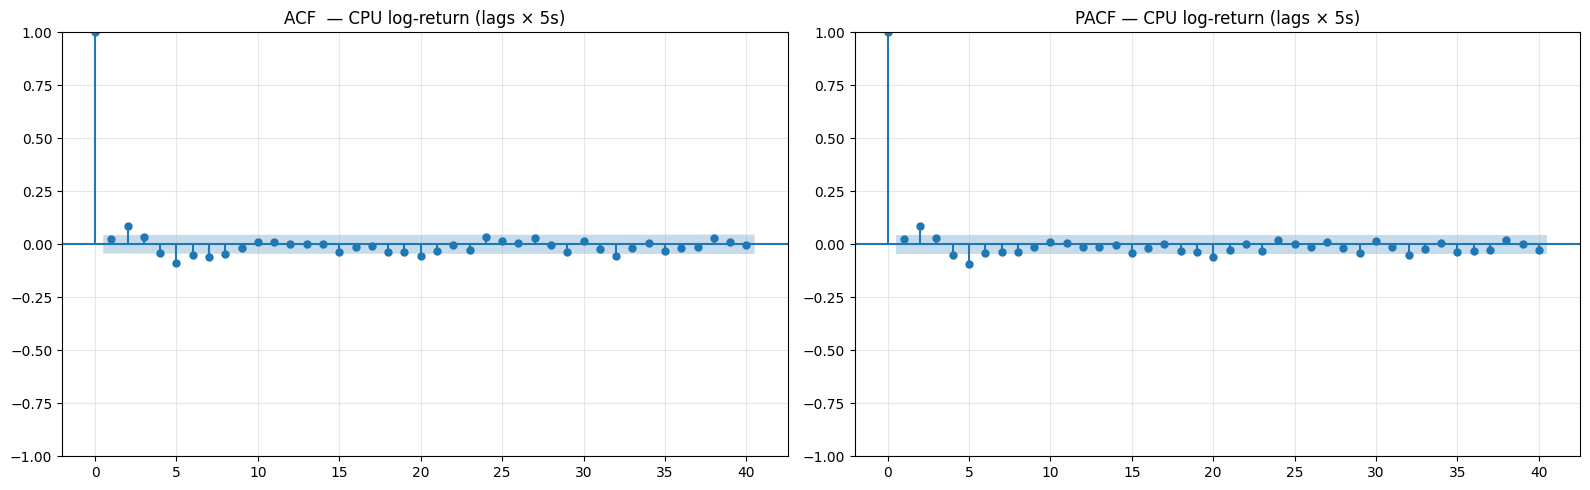

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf( lr["lr_cpu"].dropna(), lags=40, ax=axes[0], title="ACF  — CPU log-return (lags × 5s)")
plot_pacf(lr["lr_cpu"].dropna(), lags=40, ax=axes[1], title="PACF — CPU log-return (lags × 5s)")
plt.tight_layout()
plt.show()

## Крос-кореляція RPS → CPU (lag analysis)

Чи передує RPS зростанню CPU?  
Lag = N означає, що RPS у момент **t** корелює з CPU у момент **t + N×5s**.

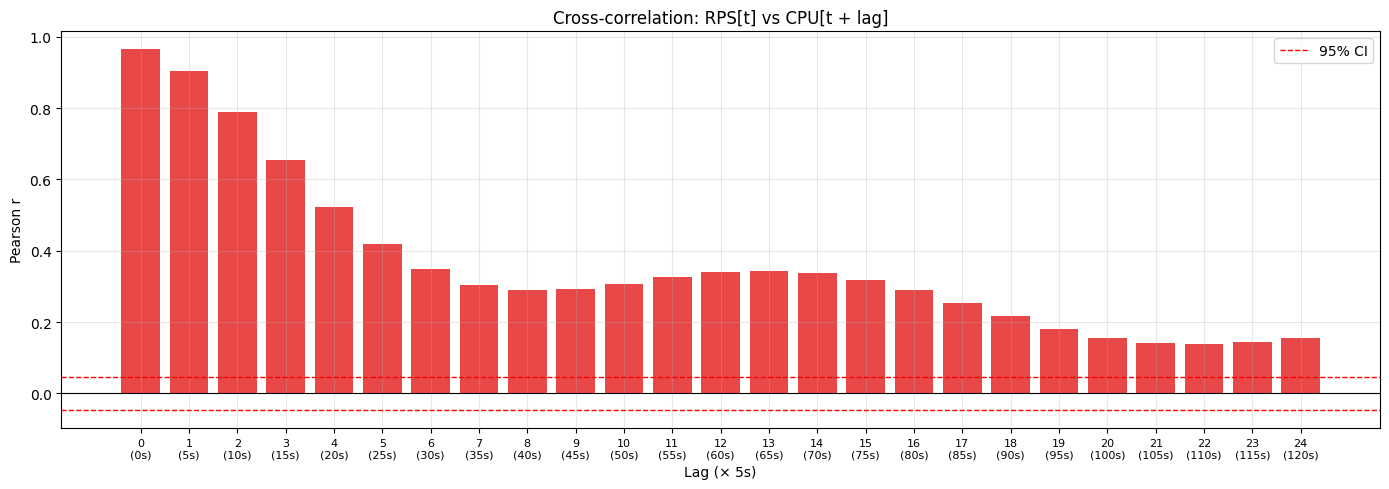

Peak correlation: r = 0.965  at lag = 0 steps (0s)


In [16]:
max_lag = 24   # 24 × 5s = 120s

rps_z = (df_active["input_rps"].values - df_active["input_rps"].mean()) / df_active["input_rps"].std()
cpu_z = (df_active["cpu_m"].values     - df_active["cpu_m"].mean())     / df_active["cpu_m"].std()

lags   = list(range(0, max_lag + 1))
xcorr  = [
    np.corrcoef(rps_z[:len(rps_z) - lag] if lag else rps_z,
                cpu_z[lag:]               if lag else cpu_z)[0, 1]
    for lag in lags
]

ci = 1.96 / np.sqrt(len(rps_z))

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [COLORS[0] if x > ci else ("#aaaaaa" if x > -ci else COLORS[1]) for x in xcorr]
ax.bar(lags, xcorr, color=bar_colors, alpha=0.8)
ax.axhline( ci, color="red", linestyle="--", linewidth=1, label="95% CI")
ax.axhline(-ci, color="red", linestyle="--", linewidth=1)
ax.axhline(0,   color="black", linewidth=0.8)
ax.set_title("Cross-correlation: RPS[t] vs CPU[t + lag]")
ax.set_xlabel("Lag (× 5s)")
ax.set_ylabel("Pearson r")
ax.set_xticks(lags)
ax.set_xticklabels([f"{l}\n({l*5}s)" for l in lags], fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

best_lag = int(np.argmax(xcorr))
print(f"Peak correlation: r = {xcorr[best_lag]:.3f}  at lag = {best_lag} steps ({best_lag * 5}s)")